I will use simple for loops for this version of Linear Regression for understanding. After getting a complete understanding of this topic i plan to use numpy for the same.

In [1]:
import numpy as np

def error_for_given_line(b,m,points):
    totalError=0
    for point in points:
        x=point[0]
        y=point[1]
        totalError+=(y-(m*x+b))**2

    return totalError/float(len(points))

def step_gradient(b,m,points,learningRate):
    b_gradient=0
    m_gradient=0
    N=float(len(points))
    for point in points:
        x=point[0]
        y=point[1]
        b_gradient+=-(2/N)*(y-(m*x-b))
        m_gradient+=-(2/N)*x*(y-(m*x-b))

    new_b=b-b_gradient*learningRate
    new_m=m-m_gradient*learningRate

    return [new_b,new_m]

def gradient_descent(initial_b,initial_m,points,learningRate,num_iterations):
    b=initial_b
    m=initial_m
    for i in range(num_iterations):
        [b,m]=step_gradient(b,m,points,learningRate)

    return [b,m]

def regression():
    points=np.genfromtxt("data.csv",delimiter=",")
    learningRate=0.0001
    initial_b=0
    initial_m=0
    num_iterations=1000
    print(f"For b={initial_b}, m={initial_m}\nError={error_for_given_line(initial_b,initial_m,points):.2f}")
    print("Running gradient descent")
    [b,m]=gradient_descent(initial_b,initial_m,points,learningRate,num_iterations)
    print(f"For b={b}, m={m}\nError={error_for_given_line(b,m,points):.2f}")
    

regression()

For b=0, m=0
Error=5565.11
Running gradient descent
For b=0.08989889221785093, m=1.4812542263671995
Error=112.65


The below code is the same as the above one, only difference is the increased use of numpy

In [4]:
import numpy as np

def error_calculation(b,m,points):
    x=points[:,0]
    y=points[:,1]
    error=(y-(m*x+b))**2
    return error.mean()

def stepGradient(b,m,points,learningRate):
    b_gradient=[]
    m_gradient=[]
    N=float(len(points))
    x=points[:,0]
    y=points[:,1]

    residual = y - (m * x + b)
    
    b_gradient = (-2/N) * residual.sum()
    m_gradient = (-2/N) * (x * residual).sum()

    new_b=b-b_gradient.sum()*learningRate
    new_m=m-m_gradient.sum()*learningRate

    return [new_b,new_m]


def gradientDescent(initial_b,initial_m,points,learningRate,num_iterations):
    b=initial_b
    m=initial_m
    for i in range(num_iterations):
        [b,m]=stepGradient(b,m,points,learningRate)

    return [b,m]

def linear_regression():
    points=np.genfromtxt("data.csv",delimiter=",")
    initial_m=0
    initial_b=0
    learningRate=0.0001
    num_iterations=1000
    print(f"For b={initial_b}, m={initial_m}\nError = {error_calculation(initial_b,initial_m,points):.2f}")
    print("Running Linear Regression......")
    [b,m]=gradientDescent(initial_b,initial_m,points,learningRate,num_iterations)
    print(f"For b={b}, m={m}\nError = {error_calculation(b,m,points):.2f}")

linear_regression()

For b=0, m=0
Error = 5565.11
Running Linear Regression......
For b=0.08893651993741349, m=1.4777440851894448
Error = 112.61


Linear Regression with Scikit-Learn Library

In [ ]:

#import pandas as pd

#data=pd.read_csv("data.csv",names=["X","y"])

#X=data.drop("y",axis=1)
#y=data["y"]

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

In [24]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2)

In [25]:
from sklearn.linear_model import LinearRegression

regression=LinearRegression().fit(X_train,y_train)

In [26]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred=regression.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 3637.80
Coefficient of determination: 0.40


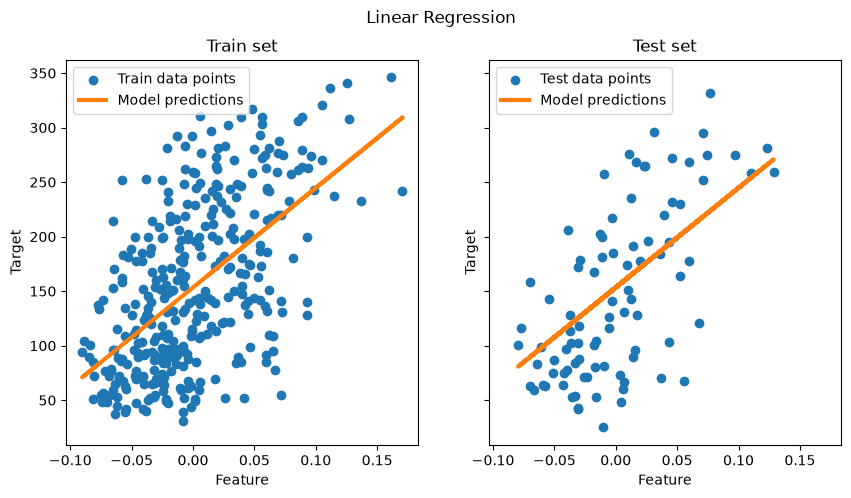

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label="Train data points")
ax[0].plot(
    X_train,
    regression.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test, y_test, label="Test data points")
ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Model predictions")
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()

It's been quite some time since i updated my code, kinda got stuck in tutorial hell of clssification, and learning scikit learn.

Something i understood is that the previous versions of Linear regression i did was only for understanding, not how ML is actually done in the industry, its mostly done by the functions of scikit learn.

I need to learn more of Scikit, the library seems vast, but luckily there are a lot of documentations and tutorials present on the internet